# Stage 2: Train Wood Genus Transfer-Learning Model

This notebook trains a transfer-learning CNN for the 17 retained WIG wood genera exported in Stage 1. It uses only the `wood_data` PNG dataset and the locked specimen-based split, so no images are re-extracted or moved between subsets.

Keras is run with the PyTorch backend. The backend must be selected before importing Keras, which is why that setting appears in the first code cell.

In [2]:
import os
os.environ["KERAS_BACKEND"] = "torch"
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    top_k_accuracy_score,
)

import keras
from keras import layers

keras.mixed_precision.set_global_policy("mixed_float16")

random.seed(42)
torch.manual_seed(42)

plt.rcParams["figure.dpi"] = 120

## Configuration

The model uses 384 x 384 inputs, weighted training examples, and two training phases: a frozen-backbone phase followed by light fine-tuning.

In [3]:
DATASET_DIR = Path("wood_data")
MANIFEST_PATH = DATASET_DIR / "manifest.csv"
IMAGE_SIZE = (384, 384)
BATCH_SIZE = 32
NUM_CLASSES = 17
HEAD_EPOCHS = 25
FINE_TUNE_EPOCHS = 10
HEAD_LR = 1e-3
FINE_TUNE_LR = 1e-5
EARLY_STOPPING_PATIENCE = 4
FROZEN_BACKBONE_MODEL_PATH = Path("wood_genus_frozen_backbone.keras")
FINE_TUNED_MODEL_PATH = Path("wood_genus_finetuned.keras")

## Load Data

Read the Stage 1 manifest and summarize the locked train, validation, and test split.

In [4]:
manifest = pd.read_csv(MANIFEST_PATH)
expected_splits = ["train", "validation", "test"]

split_summary = manifest.groupby("split").agg(
    images=("filepath", "count"),
    specimens=("specimen_id", "nunique"),
    genera=("genus", "nunique"),
).reindex(expected_splits)

genus_split_images = pd.crosstab(manifest["genus"], manifest["split"]).reindex(columns=expected_splits)

display(split_summary)
display(genus_split_images)

,images,specimens,genera
split,,,
train,4263,328,17
validation,836,69,17
test,893,69,17


split,train,validation,test
genus,,,
Acer,217,39,39
Aesculus,51,16,14
Alnus,156,42,32
Betula,87,25,24
Carpinus,204,34,29
Castanea,138,19,20
Castanopsis,217,41,40
Cinnamomum,336,60,85
Fagus,286,64,55


## Labels

Create stable integer labels for genus classification.

In [5]:
genera = sorted(manifest["genus"].unique())
genus_to_label = {genus: label_id for label_id, genus in enumerate(genera)}
label_to_genus = {label_id: genus for genus, label_id in genus_to_label.items()}
manifest["label_id"] = manifest["genus"].map(genus_to_label).astype("int64")

train_df = manifest[manifest["split"] == "train"].reset_index(drop=True)
validation_df = manifest[manifest["split"] == "validation"].reset_index(drop=True)
test_df = manifest[manifest["split"] == "test"].reset_index(drop=True)

split_counts = pd.DataFrame({
    "images": manifest.groupby("split")["filepath"].count(),
    "specimens": manifest.groupby("split")["specimen_id"].nunique(),
}).reindex(expected_splits)

display(split_counts)

,images,specimens
split,,
train,4263,328
validation,836,69
test,893,69


## Dataset and Preprocessing

Load grayscale PNGs, resize them, apply training augmentation, repeat the channel for ImageNet weights, and scale pixels to [-1, 1].

In [6]:
from PIL import ImageOps

RESAMPLE = Image.Resampling.BILINEAR


def augment_grayscale_image(image, rng=random, return_params=False):
    params = []

    if rng.random() < 0.5:
        image = ImageOps.mirror(image)
        params.append("horizontal flip")
    else:
        params.append("no horizontal flip")

    if rng.random() < 0.5:
        image = ImageOps.flip(image)
        params.append("vertical flip")
    else:
        params.append("no vertical flip")

    rotation_steps = rng.randint(0, 3)
    if rotation_steps:
        image = image.rotate(90 * rotation_steps)
    params.append(f"rotation={rotation_steps * 90}°")

    width, height = image.size
    max_shift_x = int(0.05 * width)
    max_shift_y = int(0.05 * height)
    shift_x = rng.randint(-max_shift_x, max_shift_x)
    shift_y = rng.randint(-max_shift_y, max_shift_y)
    image = image.transform(image.size, Image.Transform.AFFINE, (1, 0, shift_x, 0, 1, shift_y), resample=RESAMPLE, fillcolor=0)
    params.append(f"shift=({shift_x}px, {shift_y}px)")

    brightness_factor = rng.uniform(0.9, 1.1)
    contrast_factor = rng.uniform(0.9, 1.1)
    image = ImageEnhance.Brightness(image).enhance(brightness_factor)
    image = ImageEnhance.Contrast(image).enhance(contrast_factor)
    params.append(f"brightness={brightness_factor:.2f}")
    params.append(f"contrast={contrast_factor:.2f}")

    if return_params:
        return image, params
    return image


class WoodGenusDataset(Dataset):
    def __init__(self, dataframe, dataset_dir, augment=False, class_weight_by_label=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.dataset_dir = Path(dataset_dir)
        self.augment = augment
        self.class_weight_by_label = class_weight_by_label

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        image = Image.open(self.dataset_dir / row.filepath).convert("L")
        image = image.resize(IMAGE_SIZE, RESAMPLE)
        if self.augment:
            image = augment_grayscale_image(image)

        image_array = np.asarray(image, dtype=np.float32) / 255.0
        image_array = np.repeat(image_array[..., None], 3, axis=-1)
        image_array = (image_array * 2.0) - 1.0

        x = torch.from_numpy(image_array).float()
        y = torch.tensor(row.label_id, dtype=torch.long)

        if self.class_weight_by_label is None:
            return x, y

        sample_weight = torch.tensor(self.class_weight_by_label[int(row.label_id)], dtype=torch.float32)
        return x, y, sample_weight

### Augmentation Preview

Show one original training image and three augmented versions so the transformation settings are easy to inspect before training starts.

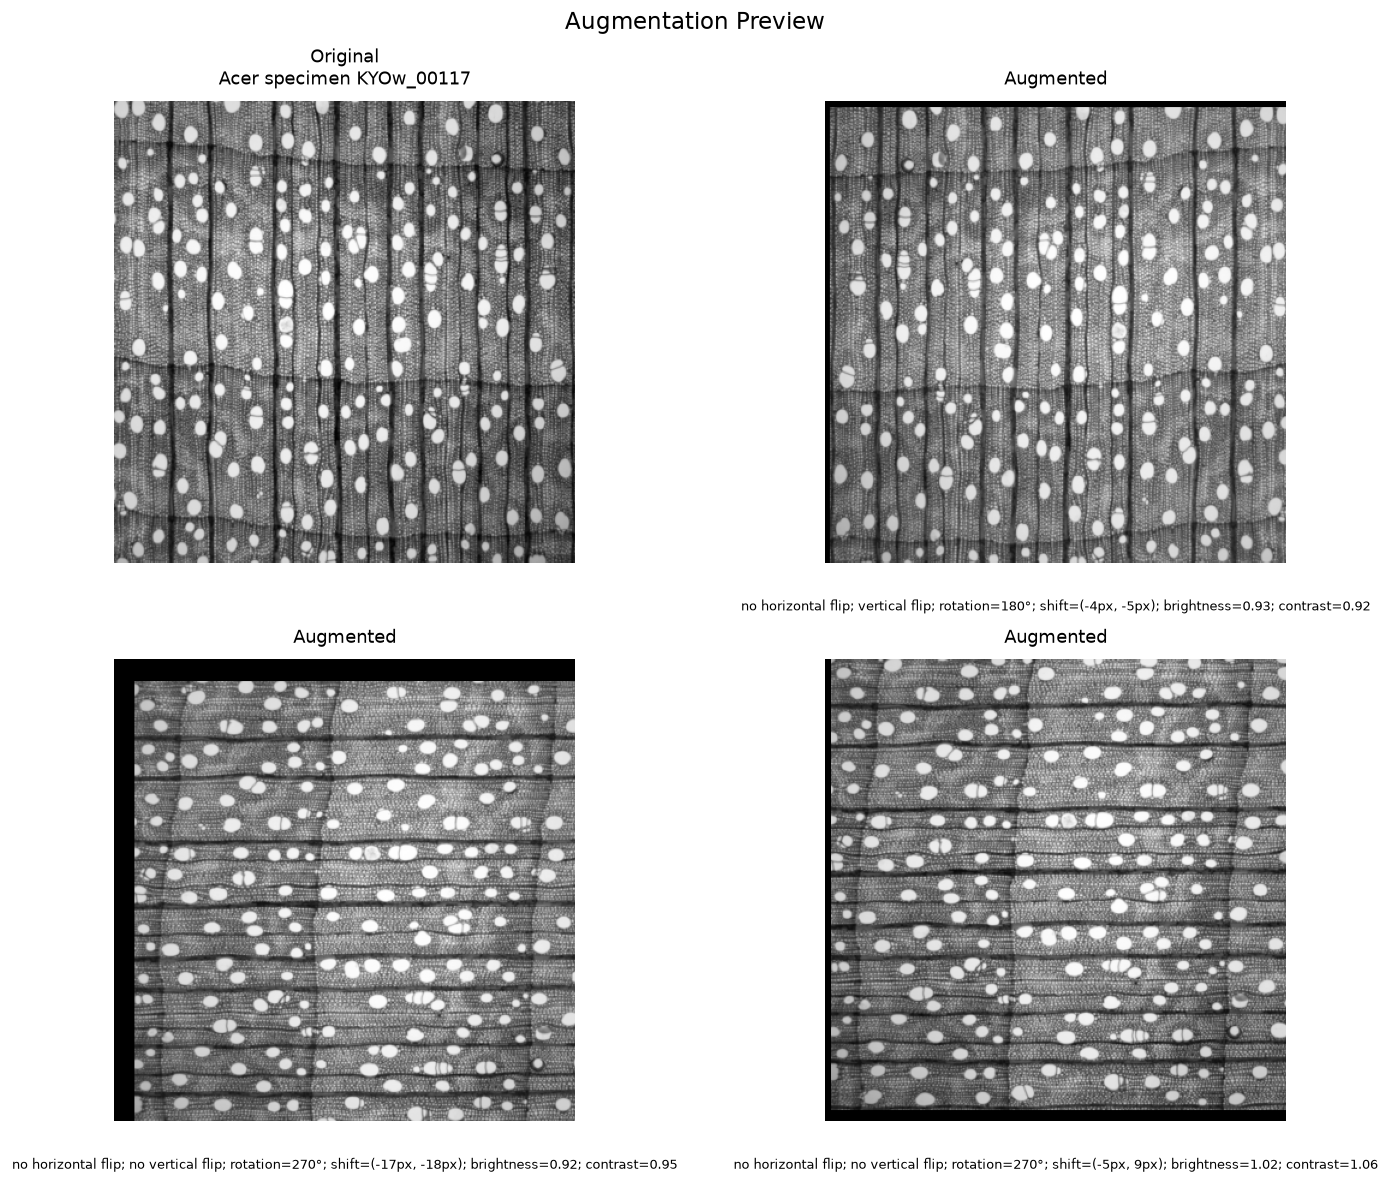

In [ ]:
preview_row = train_df.iloc[0]
preview_original = Image.open(DATASET_DIR / preview_row.filepath).convert("L").resize(IMAGE_SIZE, RESAMPLE)
preview_rng = random.Random(42)
augmented_previews = [
    augment_grayscale_image(preview_original.copy(), rng=preview_rng, return_params=True)
    for _ in range(3)
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

fig.suptitle("Augmentation Preview", fontsize=14, y=0.98)

axes[0].imshow(preview_original, cmap="gray")
axes[0].set_title(f"Original\n{preview_row.genus} specimen {preview_row.specimen_id}", fontsize=11, pad=10)
axes[0].axis("off")

for axis, (augmented_image, params) in zip(axes[1:], augmented_previews):
    axis.imshow(augmented_image, cmap="gray")
    axis.set_title("Augmented", fontsize=11, pad=10)
    axis.text(0.5, -0.08, "; ".join(params), transform=axis.transAxes, ha="center", va="top", fontsize=8, wrap=True)
    axis.axis("off")

fig.subplots_adjust(hspace=0.28, wspace=0.08, top=0.92)
plt.tight_layout()

## DataLoaders

Use shuffled training batches and ordered validation/test batches.

In [7]:
validation_dataset = WoodGenusDataset(validation_df, DATASET_DIR, augment=False)
test_dataset = WoodGenusDataset(test_df, DATASET_DIR, augment=False)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

## Class Weights

Weight classes by the number of training specimens per genus.

In [11]:
training_specimens_by_genus = train_df.groupby("genus")["specimen_id"].nunique().reindex(genera)
total_training_specimens = int(training_specimens_by_genus.sum())

class_weight_table = pd.DataFrame({
    "genus": genera,
    "training_specimens": training_specimens_by_genus.astype(int).values,
})
class_weight_table["class_weight"] = (
    total_training_specimens
    / (NUM_CLASSES * class_weight_table["training_specimens"])
)

class_weight = {
    genus_to_label[row.genus]: float(row.class_weight)
    for row in class_weight_table.itertuples(index=False)
}

train_dataset = WoodGenusDataset(
    train_df,
    DATASET_DIR,
    augment=True,
    class_weight_by_label=class_weight,
)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

display(class_weight_table)

,genus,training_specimens,class_weight
0,Acer,24,0.803922
1,Aesculus,8,2.411765
2,Alnus,13,1.484163
3,Betula,8,2.411765
4,Carpinus,17,1.134948
5,Castanea,10,1.929412
6,Castanopsis,16,1.205882
7,Cinnamomum,29,0.665314
8,Fagus,17,1.134948
9,Lindera,11,1.754011


## Model

Use ImageNet-pretrained EfficientNetV2B0 with a small wood-specific convolutional head.

In [ ]:
backbone = keras.applications.EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3),
    include_preprocessing=False,
)
backbone.trainable = False

inputs = keras.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
x = backbone(inputs, training=False)
x = layers.Conv2D(64, 3, padding="same", activation="swish", name="wood_features")(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32", name="genus_probabilities")(x)
model = keras.Model(inputs, outputs, name="wood_genus_efficientnetv2b0")
model.summary()

Model: "wood_genus_efficientnetv2b0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 12, 12, 1280)   │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ wood_features (Conv2D)          │ (None, 12, 12, 64)     │       737,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ genus_probabilities (Dense)     │ (None, 17)             │         1,105 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,657,761 (25.40 MB)

 Trainable params: 738,449 (2.82 MB)

 Non-trainable params: 5,919,312 (22.58 MB)

## Train Frozen Backbone

Train the new head while the pretrained backbone is frozen.

In [ ]:
backbone.trainable = False

model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=HEAD_LR),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

phase1_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=EARLY_STOPPING_PATIENCE,
    restore_best_weights=True,
)

history_phase1 = model.fit(
    train_loader,
    validation_data=validation_loader,
    epochs=HEAD_EPOCHS,
    callbacks=[phase1_early_stopping],
)

c:\Users\marti\anaconda3\envs\e89\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a torch DataLoader. The DataLoader is expected to already be shuffled.
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/25
134/134 ━━━━━━━━━━━━━━━━━━━━ 185s 1s/step - accuracy: 0.5787 - loss: 1.3250 - val_accuracy: 0.7273 - val_loss: 0.8372
Epoch 2/25
134/134 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.7342 - loss: 0.8008 - val_accuracy: 0.8361 - val_loss: 0.5527
Epoch 3/25
134/134 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.7713 - loss: 0.6579 - val_accuracy: 0.8445 - val_loss: 0.4345
Epoch 4/25
134/134 ━━━━━━━━━━━━━━━━━━━━ 130s 967ms/step - accuracy: 0.7987 - loss: 0.5376 - val_accuracy: 0.8672 - val_loss: 0.3548
Epoch 5/25
134/134 ━━━━━━━━━━━━━━━━━━━━ 128s 958ms/step - accuracy: 0.8316 - loss: 0.4667 - val_accuracy: 0.8852 - val_loss: 0.3451
Epoch 6/25
134/134 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.8365 - loss: 0.4652 - val_accuracy: 0.8720 - val_loss: 0.3780
Epoch 7/25
134/134 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - accuracy: 0.8593 - loss: 0.3812 - val_accuracy: 0.8720 - val_loss: 0.3065
Epoch 8/25
134/134 ━━━━━━━━━━━━━━━━━━━━ 119s 891ms/step - accuracy: 0.8707 - loss: 0.3648 -

In [ ]:
model.save(FROZEN_BACKBONE_MODEL_PATH)

In [ ]:
model = keras.models.load_model(FROZEN_BACKBONE_MODEL_PATH)
backbone = model.get_layer("efficientnetv2-b0")

## Fine-Tune Backbone

Unfreeze the final non-Batch-Normalization backbone layers and continue training with a smaller learning rate.

In [ ]:
backbone.trainable = True
for layer in backbone.layers:
    layer.trainable = False

non_bn_backbone_layers = [
    layer for layer in backbone.layers
    if not isinstance(layer, layers.BatchNormalization)
]
for layer in non_bn_backbone_layers[-20:]:
    layer.trainable = True
for layer in backbone.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=FINE_TUNE_LR),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

phase2_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=EARLY_STOPPING_PATIENCE,
    restore_best_weights=True,
)

history_phase2 = model.fit(
    train_loader,
    validation_data=validation_loader,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=[phase2_early_stopping],
)

Epoch 1/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 780s 6s/step - accuracy: 0.8980 - loss: 0.2543 - val_accuracy: 0.9067 - val_loss: 0.2550
Epoch 2/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 849s 6s/step - accuracy: 0.9048 - loss: 0.2570 - val_accuracy: 0.9043 - val_loss: 0.2588
Epoch 3/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 892s 7s/step - accuracy: 0.9073 - loss: 0.2389 - val_accuracy: 0.9139 - val_loss: 0.2492
Epoch 4/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 820s 6s/step - accuracy: 0.9132 - loss: 0.2122 - val_accuracy: 0.9067 - val_loss: 0.2508
Epoch 5/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 775s 6s/step - accuracy: 0.9125 - loss: 0.2257 - val_accuracy: 0.8983 - val_loss: 0.2596
Epoch 6/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 775s 6s/step - accuracy: 0.9059 - loss: 0.2353 - val_accuracy: 0.9043 - val_loss: 0.2594
Epoch 7/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 807s 6s/step - accuracy: 0.9148 - loss: 0.2195 - val_accuracy: 0.9043 - val_loss: 0.2573


In [ ]:
model.save(FINE_TUNED_MODEL_PATH)

In [8]:
model = keras.models.load_model(FINE_TUNED_MODEL_PATH)

## Training Curves

Plot loss and accuracy across both training phases.

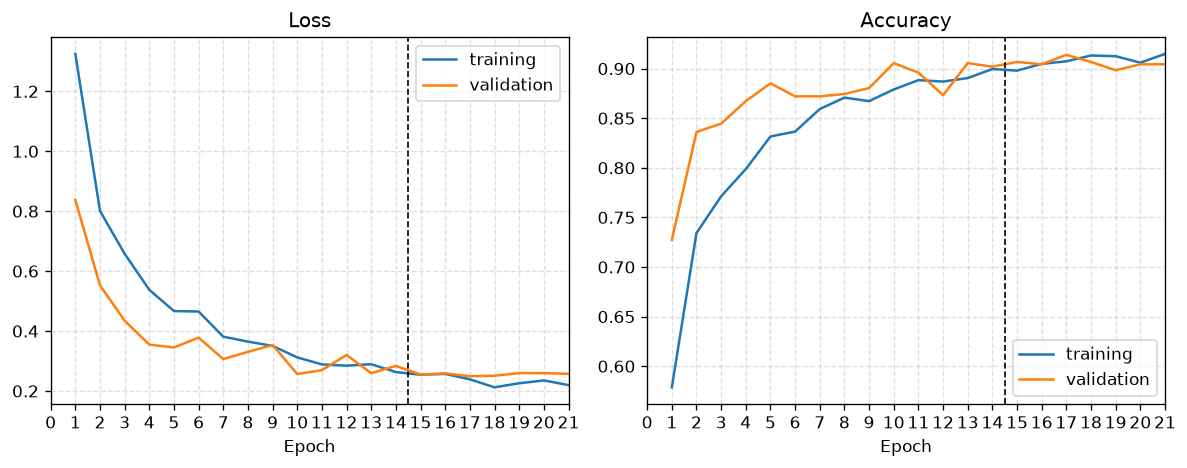

In [ ]:
def history_to_frame(history, phase):
    frame = pd.DataFrame(history.history)
    frame["phase"] = phase
    return frame

history_df = pd.concat(
    [
        history_to_frame(history_phase1, "Frozen backbone"),
        history_to_frame(history_phase2, "Fine-tuning"),
    ],
    ignore_index=True,
)
history_df["epoch"] = np.arange(1, len(history_df) + 1)
phase2_start_epoch = len(history_phase1.history["loss"]) + 1
total_epochs = len(history_df)
epoch_ticks = np.arange(0, total_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(history_df["epoch"], history_df["loss"], label="training")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="validation")
axes[0].axvline(phase2_start_epoch - 0.5, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_xlim(0, total_epochs)
axes[0].set_xticks(epoch_ticks)
axes[0].grid(True, linestyle="--", alpha=0.4)
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["accuracy"], label="training")
axes[1].plot(history_df["epoch"], history_df["val_accuracy"], label="validation")
axes[1].axvline(phase2_start_epoch - 0.5, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_xlim(0, total_epochs)
axes[1].set_xticks(epoch_ticks)
axes[1].grid(True, linestyle="--", alpha=0.4)
axes[1].legend()

plt.tight_layout()

## Image-Level Evaluation

Report top-1 accuracy and macro F1 as the main image-level metrics. Top-2 accuracy measures whether the correct genus appears among the model's two highest-probability predictions.

28/28 ━━━━━━━━━━━━━━━━━━━━ 27s 886ms/step


,accuracy,top_2_accuracy,macro_f1
Image,0.87346,0.944009,0.839173


,precision,recall,f1,support
Acer,0.882353,0.769231,0.821918,39.0
Aesculus,0.875000,1.000000,0.933333,14.0
Alnus,1.000000,0.593750,0.745098,32.0
Betula,1.000000,1.000000,1.000000,24.0
Carpinus,0.743590,1.000000,0.852941,29.0
Castanea,0.769231,1.000000,0.869565,20.0
Castanopsis,1.000000,0.950000,0.974359,40.0
Cinnamomum,0.912281,0.611765,0.732394,85.0
Fagus,0.932203,1.000000,0.964912,55.0
Lindera,0.484848,0.800000,0.603774,20.0


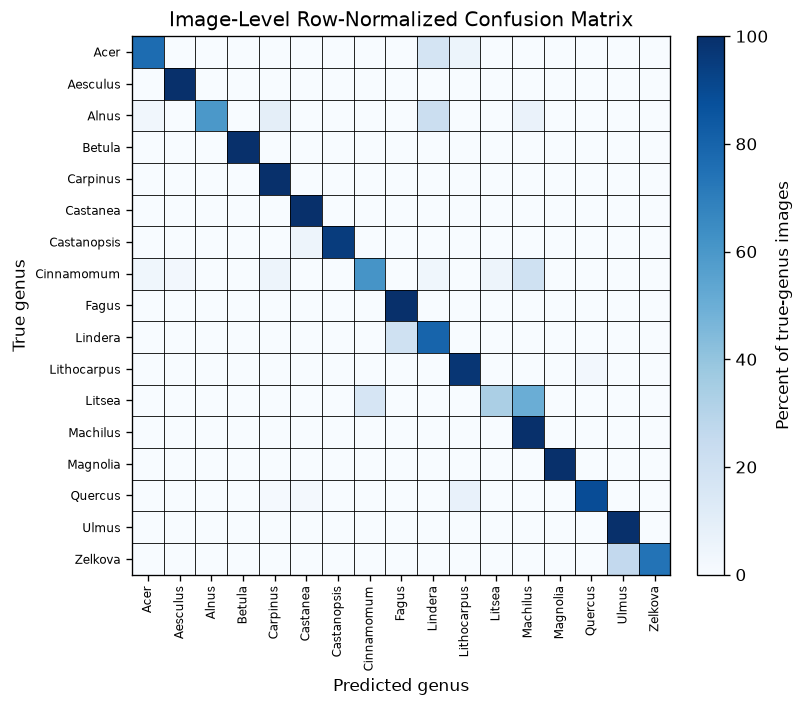

In [9]:
test_probs = np.asarray(model.predict(test_loader))
image_true_ids = test_df["label_id"].to_numpy()
image_pred_ids = test_probs.argmax(axis=1)
image_confidences = test_probs.max(axis=1)

image_accuracy = accuracy_score(image_true_ids, image_pred_ids)
image_top2_accuracy = top_k_accuracy_score(
    image_true_ids,
    test_probs,
    k=2,
    labels=np.arange(NUM_CLASSES),
)
image_macro_f1 = f1_score(image_true_ids, image_pred_ids, average="macro")
image_confusion = confusion_matrix(image_true_ids, image_pred_ids, labels=np.arange(NUM_CLASSES))
image_confusion_percent = np.divide(
    image_confusion,
    image_confusion.sum(axis=1, keepdims=True),
    out=np.zeros_like(image_confusion, dtype=float),
    where=image_confusion.sum(axis=1, keepdims=True) != 0,
) * 100
image_report = classification_report(
    image_true_ids,
    image_pred_ids,
    labels=np.arange(NUM_CLASSES),
    target_names=genera,
    output_dict=True,
    zero_division=0,
)
image_per_genus_metrics = (
    pd.DataFrame(image_report)
    .T.loc[genera, ["precision", "recall", "f1-score", "support"]]
    .rename(columns={"f1-score": "f1"})
)
image_overall_metrics = pd.DataFrame({
    "accuracy": [image_accuracy],
    "top_2_accuracy": [image_top2_accuracy],
    "macro_f1": [image_macro_f1],
}, index=["Image"])

display(image_overall_metrics)
display(image_per_genus_metrics)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(image_confusion_percent, cmap="Blues", vmin=0, vmax=100)
ax.set_title("Image-Level Row-Normalized Confusion Matrix")
ax.set_xlabel("Predicted genus")
ax.set_ylabel("True genus")
ax.set_xticks(np.arange(NUM_CLASSES))
ax.set_yticks(np.arange(NUM_CLASSES))
ax.set_xticklabels(genera, rotation=90, fontsize=7)
ax.set_yticklabels(genera, fontsize=7)
ax.set_xticks(np.arange(-0.5, NUM_CLASSES, 1), minor=True)
ax.set_yticks(np.arange(-0.5, NUM_CLASSES, 1), minor=True)
ax.grid(which="minor", color="black", linestyle="-", linewidth=0.5)
ax.tick_params(which="minor", bottom=False, left=False)
colorbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
colorbar.set_label("Percent of true-genus images")
plt.tight_layout()

## Specimen-Level Evaluation

Average image probabilities by specimen and report top-1 accuracy and macro F1 as the main metrics. Specimen-level top-2 accuracy is a secondary shortlist metric indicating whether the correct genus is among the two highest averaged probabilities.

,accuracy,top_2_accuracy,macro_f1
Specimen,0.884058,0.956522,0.864417


,precision,recall,f1,support
Acer,1.000000,0.800000,0.888889,5.0
Aesculus,1.000000,1.000000,1.000000,2.0
Alnus,1.000000,0.666667,0.800000,3.0
Betula,1.000000,1.000000,1.000000,2.0
Carpinus,1.000000,1.000000,1.000000,3.0
Castanea,1.000000,1.000000,1.000000,2.0
Castanopsis,1.000000,1.000000,1.000000,3.0
Cinnamomum,1.000000,0.666667,0.800000,6.0
Fagus,1.000000,1.000000,1.000000,3.0
Lindera,0.500000,1.000000,0.666667,2.0


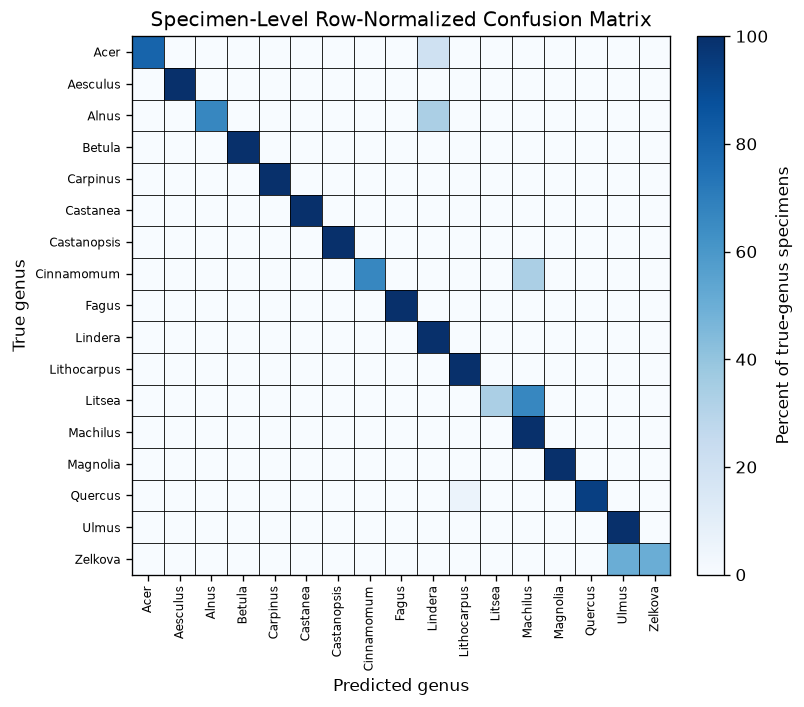

In [10]:
probability_columns = [f"prob_{genus}" for genus in genera]

test_predictions = test_df[["filepath", "specimen_id", "genus", "label_id"]].copy()
for label_id, column in enumerate(probability_columns):
    test_predictions[column] = test_probs[:, label_id]

test_predictions["predicted_label_id"] = image_pred_ids
test_predictions["predicted_genus"] = [label_to_genus[label_id] for label_id in image_pred_ids]
test_predictions["prediction_confidence"] = image_confidences

specimen_probabilities = (
    test_predictions
    .groupby(["specimen_id", "genus", "label_id"], as_index=False)[probability_columns]
    .mean()
)
specimen_probability_values = specimen_probabilities[probability_columns].to_numpy()
specimen_true_ids = specimen_probabilities["label_id"].to_numpy()
specimen_pred_ids = specimen_probability_values.argmax(axis=1)

specimen_accuracy = accuracy_score(specimen_true_ids, specimen_pred_ids)
specimen_top2_accuracy = top_k_accuracy_score(
    specimen_true_ids,
    specimen_probability_values,
    k=2,
    labels=np.arange(NUM_CLASSES),
)
specimen_macro_f1 = f1_score(specimen_true_ids, specimen_pred_ids, average="macro")
specimen_confusion = confusion_matrix(specimen_true_ids, specimen_pred_ids, labels=np.arange(NUM_CLASSES))
specimen_confusion_percent = np.divide(
    specimen_confusion,
    specimen_confusion.sum(axis=1, keepdims=True),
    out=np.zeros_like(specimen_confusion, dtype=float),
    where=specimen_confusion.sum(axis=1, keepdims=True) != 0,
) * 100
specimen_report = classification_report(
    specimen_true_ids,
    specimen_pred_ids,
    labels=np.arange(NUM_CLASSES),
    target_names=genera,
    output_dict=True,
    zero_division=0,
)
specimen_per_genus_metrics = (
    pd.DataFrame(specimen_report)
    .T.loc[genera, ["precision", "recall", "f1-score", "support"]]
    .rename(columns={"f1-score": "f1"})
)
specimen_overall_metrics = pd.DataFrame({
    "accuracy": [specimen_accuracy],
    "top_2_accuracy": [specimen_top2_accuracy],
    "macro_f1": [specimen_macro_f1],
}, index=["Specimen"])

display(specimen_overall_metrics)
display(specimen_per_genus_metrics)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(specimen_confusion_percent, cmap="Blues", vmin=0, vmax=100)
ax.set_title("Specimen-Level Row-Normalized Confusion Matrix")
ax.set_xlabel("Predicted genus")
ax.set_ylabel("True genus")
ax.set_xticks(np.arange(NUM_CLASSES))
ax.set_yticks(np.arange(NUM_CLASSES))
ax.set_xticklabels(genera, rotation=90, fontsize=7)
ax.set_yticklabels(genera, fontsize=7)
ax.set_xticks(np.arange(-0.5, NUM_CLASSES, 1), minor=True)
ax.set_yticks(np.arange(-0.5, NUM_CLASSES, 1), minor=True)
ax.grid(which="minor", color="black", linestyle="-", linewidth=0.5)
ax.tick_params(which="minor", bottom=False, left=False)
colorbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
colorbar.set_label("Percent of true-genus specimens")
plt.tight_layout()

## Summary

Collect the main counts, metrics, and saved artifact paths.

In [ ]:
best_validation_accuracy = float(history_df["val_accuracy"].max())
phase1_best_validation_accuracy = float(pd.DataFrame(history_phase1.history)["val_accuracy"].max())
phase2_best_validation_accuracy = float(pd.DataFrame(history_phase2.history)["val_accuracy"].max())
fine_tuning_improved = phase2_best_validation_accuracy > phase1_best_validation_accuracy

specimen_f1_by_genus = specimen_per_genus_metrics["f1"]
highest_specimen_f1_genus = specimen_f1_by_genus.idxmax()
lowest_specimen_f1_genus = specimen_f1_by_genus.idxmin()

summary_rows = [
    ("Training images", int(split_counts.loc["train", "images"])),
    ("Validation images", int(split_counts.loc["validation", "images"])),
    ("Test images", int(split_counts.loc["test", "images"])),
    ("Training specimens", int(split_counts.loc["train", "specimens"])),
    ("Validation specimens", int(split_counts.loc["validation", "specimens"])),
    ("Test specimens", int(split_counts.loc["test", "specimens"])),
    ("Class-weight range", f"{class_weight_table['class_weight'].min():.3f} to {class_weight_table['class_weight'].max():.3f}"),
    ("Best validation accuracy", f"{best_validation_accuracy:.3f}"),
    ("Image-level test accuracy", f"{image_accuracy:.3f}"),
    ("Image-level test top-2 accuracy", f"{image_top2_accuracy:.3f}"),
    ("Image-level test macro F1", f"{image_macro_f1:.3f}"),
    ("Specimen-level test accuracy", f"{specimen_accuracy:.3f}"),
    ("Specimen-level test top-2 accuracy", f"{specimen_top2_accuracy:.3f}"),
    ("Specimen-level test macro F1", f"{specimen_macro_f1:.3f}"),
    ("Highest specimen-level F1 genus", f"{highest_specimen_f1_genus} ({specimen_f1_by_genus.max():.3f})"),
    ("Lowest specimen-level F1 genus", f"{lowest_specimen_f1_genus} ({specimen_f1_by_genus.min():.3f})"),
    ("Fine-tuning improved validation accuracy", "yes" if fine_tuning_improved else "no"),
    ("Frozen-backbone saved model path", str(FROZEN_BACKBONE_MODEL_PATH)),
    ("Fine-tuned saved model path", str(FINE_TUNED_MODEL_PATH)),
]

summary_table = pd.DataFrame(summary_rows, columns=["item", "value"])
display(summary_table)

,item,value
0,Training images,4263
1,Validation images,836
2,Test images,893
3,Training specimens,328
4,Validation specimens,69
5,Test specimens,69
6,Class-weight range,0.241 to 2.412
7,Best validation accuracy,0.914
8,Image-level test accuracy,0.873
9,Image-level test top-2 accuracy,0.944
